# Cyclistic Bike Share Analysis
## 03 — Exploratory Data Analysis

### Business Question
How do annual members and casual riders use Cyclistic bikes differently?

### Analysis Objectives
This notebook compares casual riders and annual members across:

- total ride volume;
- share of rides;
- ride duration;
- weekday behaviour;
- weekday versus weekend behaviour;
- hour of day;
- monthly trends;
- seasonal patterns;
- bike type.

The purpose is to identify behavioural differences that can support evidence-based business recommendations.

In [2]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------------- -------------------------- 3.1/9.5 MB 29.8 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.5 MB 21.0 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 20.8 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 37.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   --------------------------------- ------ 6.0/7.2 MB 31.6 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 30.5 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ------------------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
cwd = Path.cwd()

if (cwd / "03_cleaned_data").exists():
    project_path = cwd
elif (cwd.parent / "03_cleaned_data").exists():
    project_path = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the Cyclistic project folder."
    )

cleaned_file = (
    project_path
    / "03_cleaned_data"
    / "cyclistic_202507_202606_cleaned.parquet"
)

visualization_path = (
    project_path
    / "05_visualizations"
)

documentation_path = (
    project_path
    / "06_documentation"
)

analysis_output_path = (
    project_path
    / "04_analysis"
    / "outputs"
)

visualization_path.mkdir(exist_ok=True)
documentation_path.mkdir(exist_ok=True)
analysis_output_path.mkdir(exist_ok=True)

print("Cleaned file:")
print(cleaned_file)
print("\nFile exists:", cleaned_file.exists())

Cleaned file:
c:\Users\OLUWATOSIN OLUWASEUN\Downloads\Cyclistic_Bike_Share_Case_Study\03_cleaned_data\cyclistic_202507_202606_cleaned.parquet

File exists: True


In [5]:
df = pd.read_parquet(cleaned_file)

print("Cleaned dataset loaded.")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")

Cleaned dataset loaded.
Rows: 5,926,670
Columns: 23


In [6]:
print("=" * 60)
print("ANALYSIS DATA VALIDATION")
print("=" * 60)

print(f"Rows:                 {len(df):,}")
print(f"Unique ride IDs:      {df['ride_id'].nunique():,}")
print(f"Duplicate ride IDs:   {df['ride_id'].duplicated().sum():,}")
print(f"Study months:         {df['month'].nunique()}")
print(f"Minimum duration:     {df['ride_length_minutes'].min():.2f}")
print(f"Maximum duration:     {df['ride_length_minutes'].max():.2f}")

print("\nRider types:")
print(df["member_casual"].value_counts(dropna=False))

ANALYSIS DATA VALIDATION
Rows:                 5,926,670
Unique ride IDs:      5,926,670
Duplicate ride IDs:   0
Study months:         12
Minimum duration:     0.00
Maximum duration:     1439.98

Rider types:
member_casual
member    3814623
casual    2112047
Name: count, dtype: int64[pyarrow]


In [7]:
rider_summary = (
    df.groupby("member_casual")
    .agg(
        total_rides=("ride_id", "count"),
        average_ride_minutes=("ride_length_minutes", "mean"),
        median_ride_minutes=("ride_length_minutes", "median")
    )
    .reset_index()
)

rider_summary["ride_share_percent"] = (
    rider_summary["total_rides"]
    / rider_summary["total_rides"].sum()
    * 100
)

rider_summary

,member_casual,total_rides,average_ride_minutes,median_ride_minutes,ride_share_percent
0,casual,2112047,18.57,11.13,35.64
1,member,3814623,12.06,8.58,64.36


In [8]:
rider_summary_display = rider_summary.copy()

rider_summary_display["average_ride_minutes"] = (
    rider_summary_display["average_ride_minutes"].round(2)
)

rider_summary_display["median_ride_minutes"] = (
    rider_summary_display["median_ride_minutes"].round(2)
)

rider_summary_display["ride_share_percent"] = (
    rider_summary_display["ride_share_percent"].round(2)
)

rider_summary_display

,member_casual,total_rides,average_ride_minutes,median_ride_minutes,ride_share_percent
0,casual,2112047,18.57,11.13,35.64
1,member,3814623,12.06,8.58,64.36


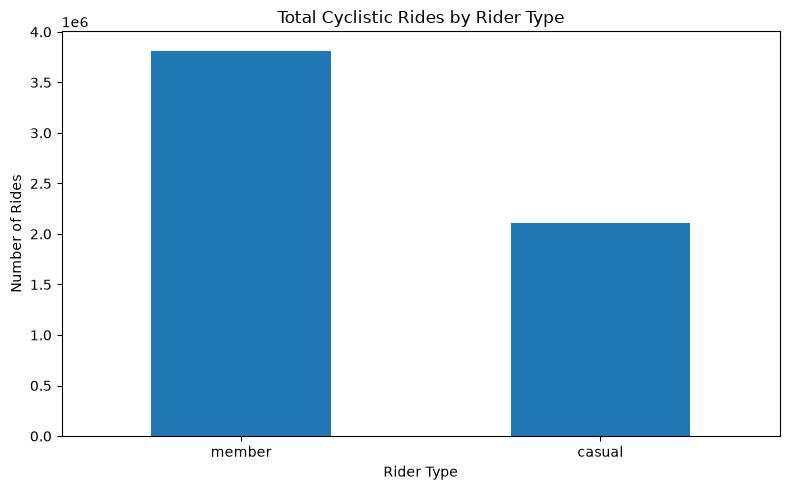

In [9]:
ride_counts = (
    df["member_casual"]
    .value_counts()
)

ax = ride_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Total Cyclistic Rides by Rider Type")
ax.set_xlabel("Rider Type")
ax.set_ylabel("Number of Rides")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    visualization_path / "01_total_rides_by_rider_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
duration_by_rider = (
    df.groupby("member_casual")
    ["ride_length_minutes"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max",
            "std"
        ]
    )
    .round(2)
)

duration_by_rider

,count,mean,median,min,max,std
member_casual,,,,,,
casual,2112047,18.57,11.13,0.00,"1,439.98",37.12
member,3814623,12.06,8.58,0.00,"1,439.90",21.65


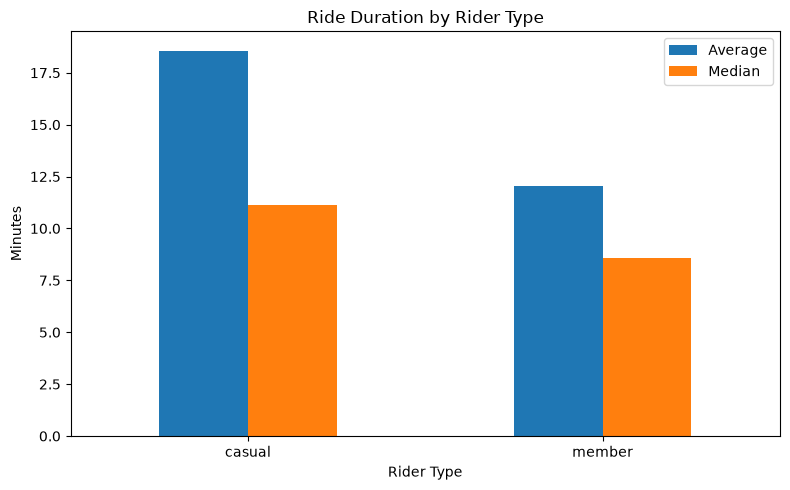

In [11]:
duration_chart = (
    df.groupby("member_casual")
    ["ride_length_minutes"]
    .agg(
        Average="mean",
        Median="median"
    )
)

ax = duration_chart.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Ride Duration by Rider Type")
ax.set_xlabel("Rider Type")
ax.set_ylabel("Minutes")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    visualization_path / "02_ride_duration_by_rider_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

df["day_of_week"] = pd.Categorical(
    df["day_of_week"],
    categories=day_order,
    ordered=True
)

In [13]:
rides_by_day = (
    df.groupby(
        ["day_of_week", "member_casual"],
        observed=True
    )
    .size()
    .reset_index(name="total_rides")
)

rides_by_day

,day_of_week,member_casual,total_rides
0,Monday,casual,245229
1,Monday,member,535499
2,Tuesday,casual,244497
3,Tuesday,member,618675
4,Wednesday,casual,235036
5,Wednesday,member,602451
6,Thursday,casual,264025
7,Thursday,member,608924
8,Friday,casual,330712
9,Friday,member,559810


In [14]:
rides_by_day_pivot = (
    rides_by_day
    .pivot(
        index="day_of_week",
        columns="member_casual",
        values="total_rides"
    )
)

rides_by_day_pivot

member_casual,casual,member
day_of_week,,
Monday,245229,535499
Tuesday,244497,618675
Wednesday,235036,602451
Thursday,264025,608924
Friday,330712,559810
Saturday,445387,483443
Sunday,347161,405821


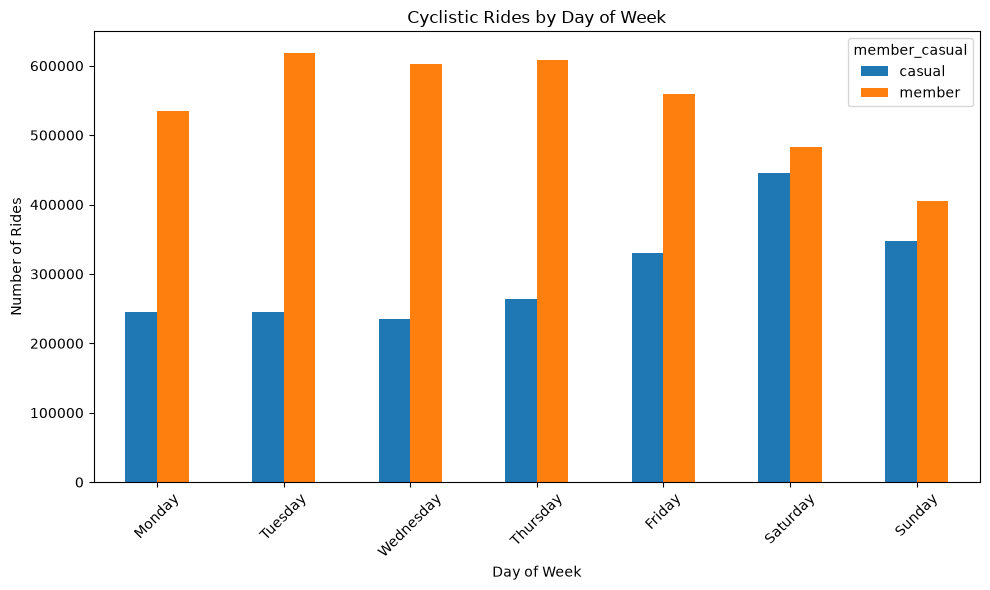

In [15]:
ax = rides_by_day_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Cyclistic Rides by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Number of Rides")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    visualization_path / "03_rides_by_day_of_week.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
df["day_type"] = np.where(
    df["is_weekend"],
    "Weekend",
    "Weekday"
)

weekend_summary = (
    df.groupby(
        ["member_casual", "day_type"]
    )
    .agg(
        total_rides=("ride_id", "count"),
        average_duration=("ride_length_minutes", "mean"),
        median_duration=("ride_length_minutes", "median")
    )
    .reset_index()
)

weekend_summary[
    ["average_duration", "median_duration"]
] = weekend_summary[
    ["average_duration", "median_duration"]
].round(2)

weekend_summary

,member_casual,day_type,total_rides,average_duration,median_duration
0,casual,Weekday,1319499,16.96,10.24
1,casual,Weekend,792548,21.24,12.94
2,member,Weekday,2925359,11.71,8.40
3,member,Weekend,889264,13.24,9.25


In [17]:
rides_by_hour = (
    df.groupby(
        ["start_hour", "member_casual"]
    )
    .size()
    .reset_index(name="total_rides")
)

rides_by_hour.head()

,start_hour,member_casual,total_rides
0,0,casual,43111
1,0,member,35220
2,1,casual,28120
3,1,member,21479
4,2,casual,18247


In [18]:
rides_by_hour_pivot = (
    rides_by_hour
    .pivot(
        index="start_hour",
        columns="member_casual",
        values="total_rides"
    )
)

rides_by_hour_pivot

member_casual,casual,member
start_hour,,
0,43111,35220
1,28120,21479
2,18247,12859
3,10171,8372
4,8213,9392
5,12864,37010
6,28318,108296
7,52055,215413
8,74722,278840


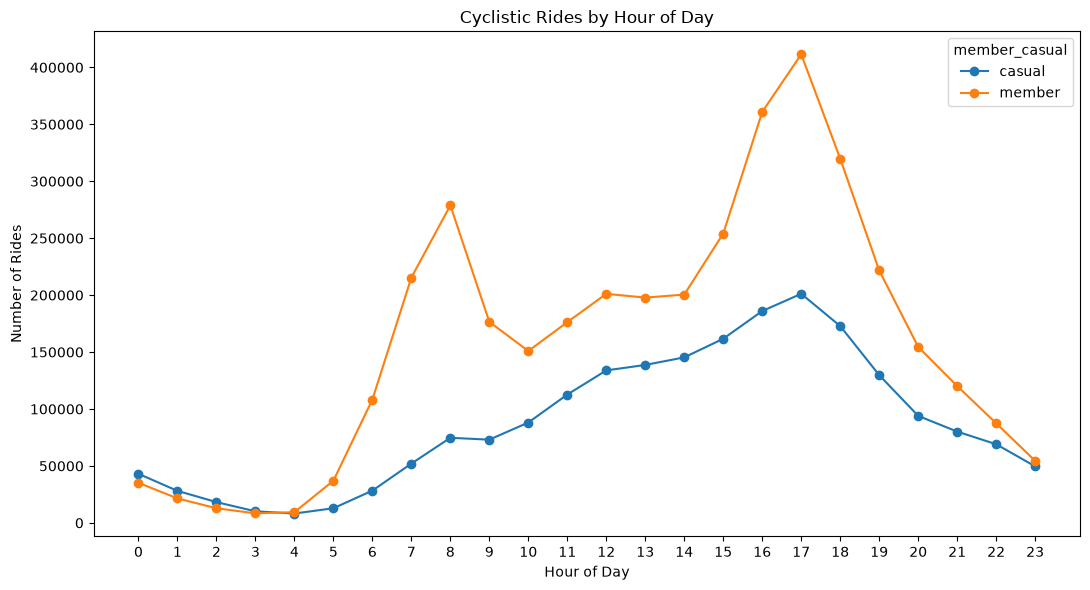

In [19]:
ax = rides_by_hour_pivot.plot(
    kind="line",
    figsize=(11, 6),
    marker="o"
)

ax.set_title("Cyclistic Rides by Hour of Day")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Rides")

ax.set_xticks(range(0, 24))

plt.tight_layout()

plt.savefig(
    visualization_path / "04_rides_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
month_order = [
    "2025-07",
    "2025-08",
    "2025-09",
    "2025-10",
    "2025-11",
    "2025-12",
    "2026-01",
    "2026-02",
    "2026-03",
    "2026-04",
    "2026-05",
    "2026-06"
]

df["month"] = pd.Categorical(
    df["month"],
    categories=month_order,
    ordered=True
)

In [21]:
rides_by_month = (
    df.groupby(
        ["month", "member_casual"],
        observed=True
    )
    .size()
    .reset_index(name="total_rides")
)

rides_by_month

,month,member_casual,total_rides
0,2025-07,casual,322505
1,2025-07,member,439965
2,2025-08,casual,337246
3,2025-08,member,452355
4,2025-09,casual,264772
5,2025-09,member,449202
6,2025-10,casual,223569
7,2025-10,member,421921
8,2025-11,casual,98871
9,2025-11,member,257292


In [22]:
rides_by_month_pivot = (
    rides_by_month
    .pivot(
        index="month",
        columns="member_casual",
        values="total_rides"
    )
)

rides_by_month_pivot

member_casual,casual,member
month,,
2025-07,322505,439965
2025-08,337246,452355
2025-09,264772,449202
2025-10,223569,421921
2025-11,98871,257292
2025-12,28005,112415
2026-01,24656,112933
2026-02,41088,160251
2026-03,87631,229121


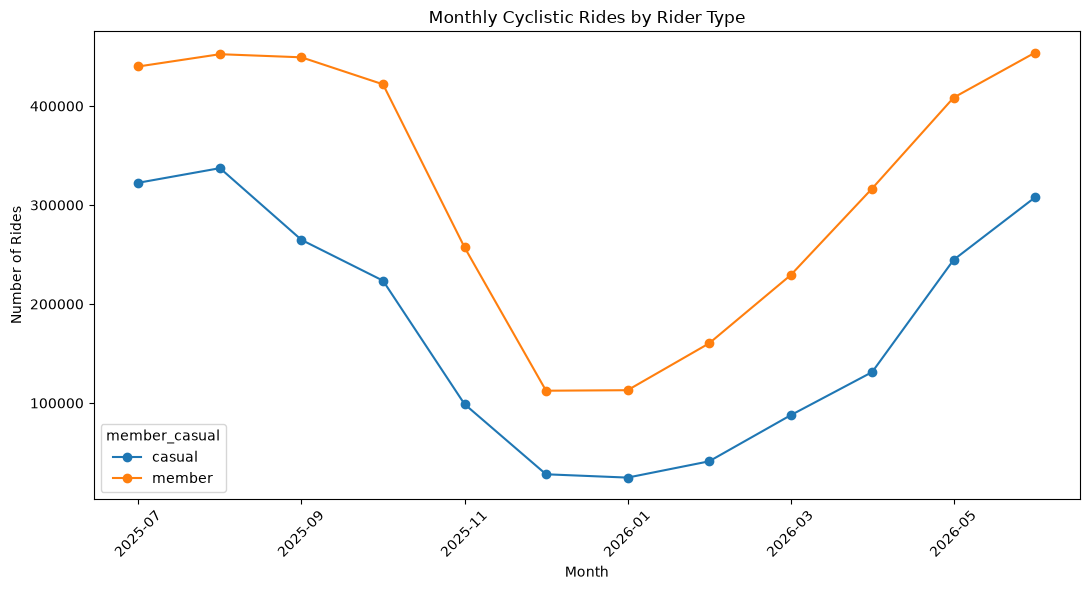

In [23]:
ax = rides_by_month_pivot.plot(
    kind="line",
    figsize=(11, 6),
    marker="o"
)

ax.set_title("Monthly Cyclistic Rides by Rider Type")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Rides")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    visualization_path / "05_monthly_rides.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]

season_summary = (
    df.groupby(
        ["season", "member_casual"]
    )
    .agg(
        total_rides=("ride_id", "count"),
        average_duration=("ride_length_minutes", "mean"),
        median_duration=("ride_length_minutes", "median")
    )
    .reset_index()
)

season_summary[
    ["average_duration", "median_duration"]
] = season_summary[
    ["average_duration", "median_duration"]
].round(2)

season_summary

,season,member_casual,total_rides,average_duration,median_duration
0,Autumn,casual,587212,17.60,10.46
1,Autumn,member,1128415,11.99,8.53
2,Spring,casual,463508,17.72,10.49
3,Spring,member,954306,11.61,8.20
4,Summer,casual,967578,20.09,12.37
5,Summer,member,1346303,12.75,9.37
6,Winter,casual,93749,13.10,7.50
7,Winter,member,385599,11.02,7.20


In [25]:
bike_type_summary = (
    df.groupby(
        ["rideable_type", "member_casual"]
    )
    .size()
    .reset_index(name="total_rides")
)

bike_type_summary

,rideable_type,member_casual,total_rides
0,classic_bike,casual,630373
1,classic_bike,member,1283897
2,electric_bike,casual,1481674
3,electric_bike,member,2530726


In [26]:
bike_type_summary["percentage_within_rider_type"] = (
    bike_type_summary
    .groupby("member_casual")["total_rides"]
    .transform(
        lambda x: x / x.sum() * 100
    )
)

bike_type_summary[
    "percentage_within_rider_type"
] = bike_type_summary[
    "percentage_within_rider_type"
].round(2)

bike_type_summary

,rideable_type,member_casual,total_rides,percentage_within_rider_type
0,classic_bike,casual,630373,29.85
1,classic_bike,member,1283897,33.66
2,electric_bike,casual,1481674,70.15
3,electric_bike,member,2530726,66.34


In [27]:
kpi_summary = (
    df.groupby("member_casual")
    .agg(
        total_rides=("ride_id", "count"),
        average_ride_minutes=("ride_length_minutes", "mean"),
        median_ride_minutes=("ride_length_minutes", "median"),
        most_common_hour=(
            "start_hour",
            lambda x: x.mode().iloc[0]
        ),
        most_common_day=(
            "day_of_week",
            lambda x: x.mode().iloc[0]
        )
    )
    .reset_index()
)

kpi_summary["ride_share_percent"] = (
    kpi_summary["total_rides"]
    / kpi_summary["total_rides"].sum()
    * 100
)

kpi_summary[
    [
        "average_ride_minutes",
        "median_ride_minutes",
        "ride_share_percent"
    ]
] = kpi_summary[
    [
        "average_ride_minutes",
        "median_ride_minutes",
        "ride_share_percent"
    ]
].round(2)

kpi_summary

,member_casual,total_rides,average_ride_minutes,median_ride_minutes,most_common_hour,most_common_day,ride_share_percent
0,casual,2112047,18.57,11.13,17,Saturday,35.64
1,member,3814623,12.06,8.58,17,Tuesday,64.36


In [28]:
rider_summary.to_csv(
    analysis_output_path / "rider_summary.csv",
    index=False
)

rides_by_day.to_csv(
    analysis_output_path / "rides_by_day.csv",
    index=False
)

rides_by_hour.to_csv(
    analysis_output_path / "rides_by_hour.csv",
    index=False
)

rides_by_month.to_csv(
    analysis_output_path / "rides_by_month.csv",
    index=False
)

season_summary.to_csv(
    analysis_output_path / "season_summary.csv",
    index=False
)

bike_type_summary.to_csv(
    analysis_output_path / "bike_type_summary.csv",
    index=False
)

weekend_summary.to_csv(
    analysis_output_path / "weekend_summary.csv",
    index=False
)

kpi_summary.to_csv(
    analysis_output_path / "kpi_summary.csv",
    index=False
)

print("Analysis summary files exported successfully.")

Analysis summary files exported successfully.


In [29]:
rider_summary_display

,member_casual,total_rides,average_ride_minutes,median_ride_minutes,ride_share_percent
0,casual,2112047,18.57,11.13,35.64
1,member,3814623,12.06,8.58,64.36


In [30]:
rides_by_day_pivot

member_casual,casual,member
day_of_week,,
Monday,245229,535499
Tuesday,244497,618675
Wednesday,235036,602451
Thursday,264025,608924
Friday,330712,559810
Saturday,445387,483443
Sunday,347161,405821


In [31]:
rides_by_hour_pivot

member_casual,casual,member
start_hour,,
0,43111,35220
1,28120,21479
2,18247,12859
3,10171,8372
4,8213,9392
5,12864,37010
6,28318,108296
7,52055,215413
8,74722,278840


In [32]:
rides_by_month_pivot

member_casual,casual,member
month,,
2025-07,322505,439965
2025-08,337246,452355
2025-09,264772,449202
2025-10,223569,421921
2025-11,98871,257292
2025-12,28005,112415
2026-01,24656,112933
2026-02,41088,160251
2026-03,87631,229121


# Exploratory Analysis Summary

## Business Question

How do annual members and casual riders use Cyclistic bikes differently?

## Key Findings

### 1. Members account for most rides, while casual riders take longer trips

Annual members completed 3,814,623 rides, representing 64.36% of all trips in the cleaned dataset.

Casual riders completed 2,112,047 rides, representing 35.64% of all trips.

Although members completed more rides overall, casual riders stayed on bikes for longer per trip:

- Casual average ride duration: 18.57 minutes
- Member average ride duration: 12.06 minutes
- Casual median ride duration: 11.13 minutes
- Member median ride duration: 8.58 minutes

This suggests that members use Cyclistic more frequently, while casual riders tend to take longer individual trips.

### 2. Member usage is more concentrated on weekdays

Member rides were strongest during the working week, particularly:

- Tuesday: 618,675 rides
- Thursday: 608,924 rides
- Wednesday: 602,451 rides

Member activity declined during the weekend.

Casual rider activity followed a different pattern. Saturday was the busiest casual-rider day, with 445,387 rides, followed by Sunday and Friday.

Approximately 37.5% of casual rides occurred on weekends, compared with approximately 23.3% of member rides.

This indicates that casual riding is more weekend-oriented, while member usage is more concentrated during weekdays.

### 3. Members show stronger morning and evening travel peaks

Member usage shows clear peaks during traditional morning and late-afternoon travel periods.

Notable member ride volumes include:

- 8:00 AM: 278,840 rides
- 5:00 PM: 411,479 rides

Approximately 46.2% of member rides occurred during the combined 7:00–9:00 AM and 4:00–6:00 PM periods.

Casual usage increased more gradually during the day and peaked at 5:00 PM with 201,167 rides.

Approximately 36.0% of casual rides occurred during the same morning and evening periods.

Combined with the weekday analysis, the member pattern is consistent with more routine or commute-oriented travel. However, the dataset does not contain trip-purpose information, so this should be treated as behavioural evidence rather than direct proof of commuting.

### 4. Casual rider usage is more strongly seasonal

Both rider groups show clear seasonal variation, but casual riders are more affected by seasonality.

Casual rides reached their highest monthly level in August 2025 with 337,246 rides.

Usage then declined significantly during winter:

- December 2025: 28,005 casual rides
- January 2026: 24,656 casual rides

Casual activity recovered strongly in spring and early summer, reaching 307,827 rides in June 2026.

Member usage also declined during winter but remained more stable throughout the year.

Member rides peaked in June 2026 with 453,983 rides.

This indicates that casual riders are more strongly concentrated in warmer months, while member usage remains comparatively consistent throughout the year.

## Overall Interpretation

The analysis identifies several clear behavioural differences between annual members and casual riders.

Annual members:

- account for the majority of total rides;
- tend to take shorter individual trips;
- ride more frequently during weekdays;
- show pronounced morning and late-afternoon usage peaks;
- maintain relatively consistent usage throughout the year.

Casual riders:

- account for a smaller share of overall rides;
- take longer trips on average;
- are more active during weekends;
- have less pronounced morning travel peaks;
- show stronger seasonal variation, with substantially higher activity during warmer months.

These differences provide a foundation for developing targeted marketing strategies aimed at converting suitable casual riders into annual members.

## Next Step

The next stage of the project is to communicate these findings through a professional Power BI dashboard and then develop three evidence-based business recommendations.